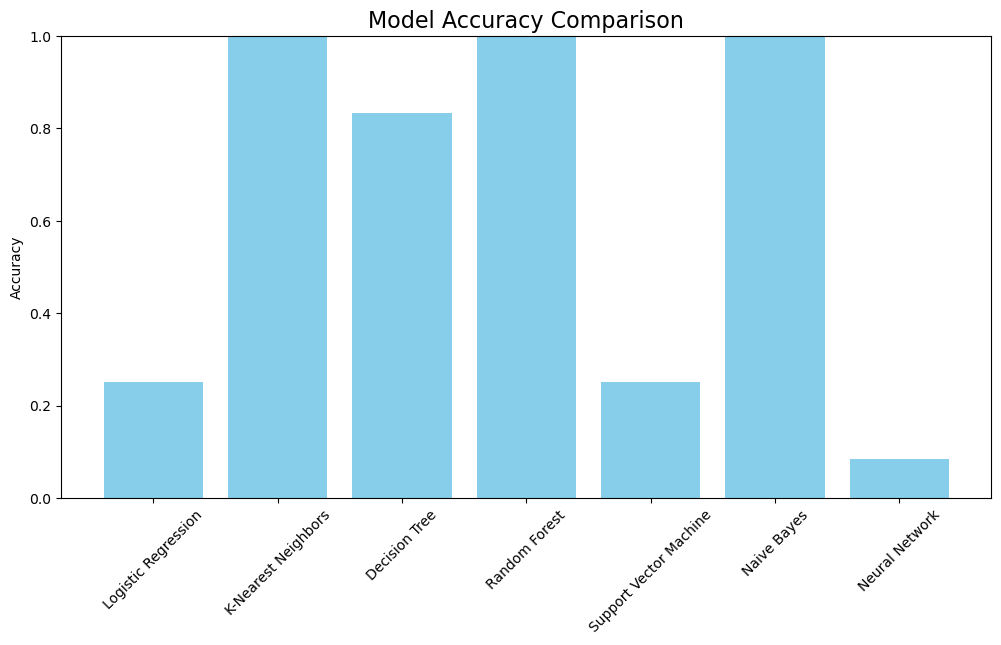

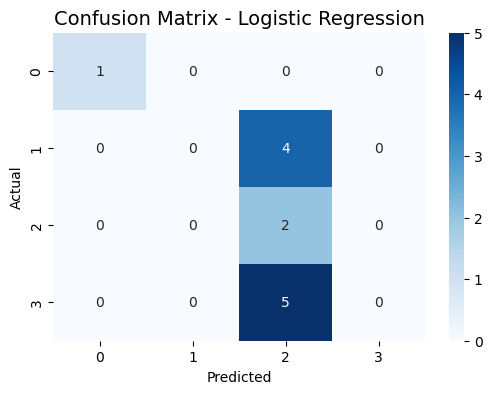

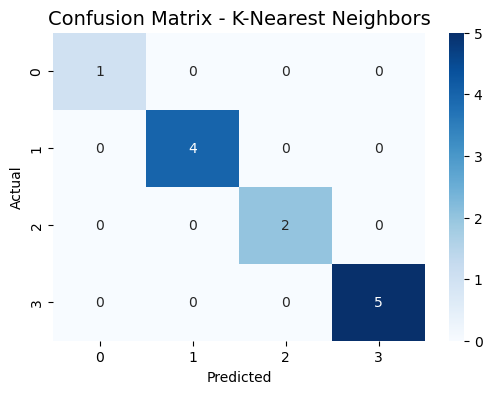

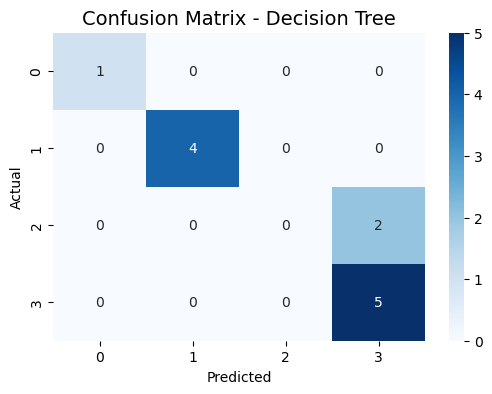

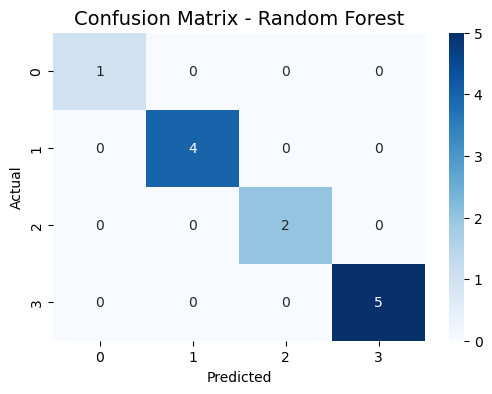

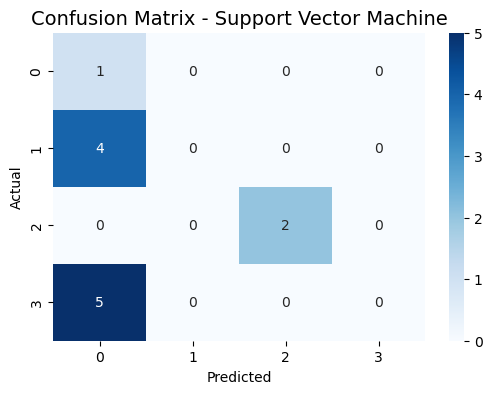

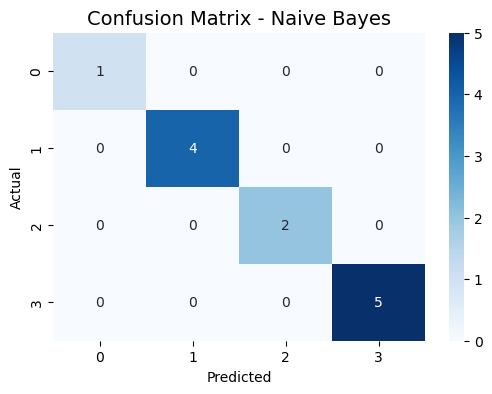

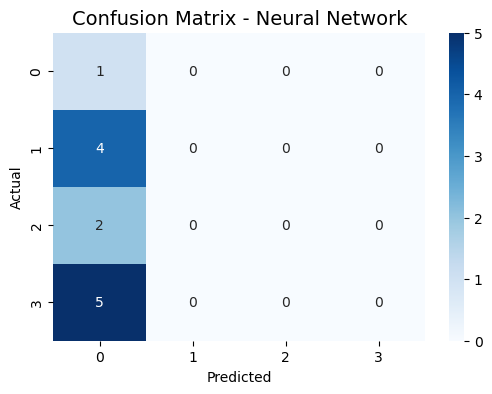

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Load CSV File
# -------------------------------
data = pd.read_csv(r"C:\Users\USER\Documents\GitHub\ml-class\input.csv")

# -------------------------------
# Define Label Column
# -------------------------------
label_column = "City"     # Label

# -------------------------------
# Split Features & Label
# -------------------------------
X = data.drop(label_column, axis=1)
y = data[label_column]

# -------------------------------
# Encode Categorical Variables
# -------------------------------
y = LabelEncoder().fit_transform(y)
X = pd.get_dummies(X)   # Encode Name column

# -------------------------------
# Train-test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -------------------------------
# Import Models
# -------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=100000, solver="liblinear"),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

# -------------------------------
# Train & Collect Accuracies
# -------------------------------
accuracies = {}
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracies[name] = accuracy_score(y_test, y_pred)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# -------------------------------
# GRAPH 1 — Accuracy Comparison
# -------------------------------
plt.figure(figsize=(12, 6))
plt.bar(accuracies.keys(), accuracies.values(), color="skyblue")
plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

# -------------------------------
# GRAPH 2 — Confusion Matrices
# -------------------------------
for name, cm in conf_matrices.items():
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
